## Background

**Dataset:** `sklearn.datasets.make_moons`

`make_moons` is a synthetic dataset from `sklearn` that generates a **two-class, two-dimensional** dataset shaped like two half-circles. Because the boundary between classes is curved, **no linear decision boundary can cleanly separate them**. In this lab, we will compare the three different SVM Kernels to see which performs best.



## Step 1: Setup: Load Libraries and Generate Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)

Class distribution:
1    1000
0    1000
Name: count, dtype: int64


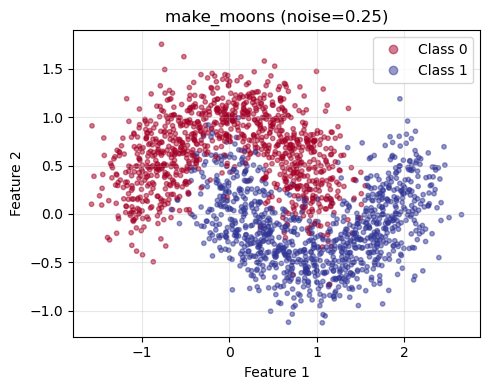

In [2]:
# The `noise` parameter adds Gaussian noise to the coordinates
# Higher noise blurs the boundary and makes the problem harder
# Too little noise makes it trivial

X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)

print(f"Class distribution:\n{pd.Series(y).value_counts()}")

fig, ax = plt.subplots(figsize=(5, 4))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.5)
handles, _ = scatter.legend_elements()
ax.legend(handles, ['Class 0', 'Class 1'])
ax.set_title('make_moons (noise=0.25)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The dataset has two features and two balanced classes:

| Feature | Description |
|---------|-------------|
| `X[:, 0]` | x-coordinate (with noise) |
| `X[:, 1]` | y-coordinate (with noise) |



## Step 2: Preprocessing

SVMs are scale-variant, so we always apply `StandardScaler` before fitting. Split your data using `train_test_split` with a test_size of 0.3,  `random_state = 42`, and `stratify = y`. 

In [3]:
# Extract training set 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Scaling: Fit the scaler ONLY on training set
scaler = StandardScaler().fit(X_train)

# Transform ONLY on X
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

## Background: Support Vector Classifier

The **support vector classifier** (SVC) fits a linear decision boundary by maximizing the margin between classes while allowing some observations to violate it. The penalty hyperparameter `C` controls how harshly violations are penalized:

- **Large C**( 100 to 1000): violations penalized heavily → narrow margin, fewer support vectors, tighter fit to training data
- **Small C** ( 0.0001 to 1): violations tolerated → wide margin, more support vectors, smoother boundary

## Step 3: Tune a Linear SVM with GridSearchCV

---

Use `GridSearchCV` with 5-fold cross-validation, search over the following values of `C` to find the best linear kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: .001, .01, 0.1, 1, 10, 100



In [4]:
# Create a parameter grid for a linear kernel configuration
linear_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
    }

# Search over the parameter grid values to find the best linear kernel configuration
linear_grid = GridSearchCV(
    SVC(random_state=42, kernel='linear'),
    param_grid=linear_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

# Fit the grid search
linear_grid.fit(X_train_scaled, y_train)

# Find the best parameter in the gird search
linear_best_params = linear_grid.best_params_
print(f"Best parameters:  {linear_best_params}")

# Retrieve the best model found
linear_best_model = linear_grid.best_estimator_
print(f"Best model: {linear_best_model}")

# Retrieve the accuracy on the test set
linear_test_acc = accuracy_score(y_test,
                                linear_best_model.predict(X_test_scaled))
print(f"Test Accuracy: {linear_test_acc:.3f}")

# Find the cross-validated accuracy
linear_cv_acc = linear_grid.best_score_
print(f"CV accuracy: {linear_cv_acc:.3f}")

Best parameters:  {'C': 1}
Best model: SVC(C=1, kernel='linear', random_state=42)
Test Accuracy: 0.880
CV accuracy: 0.860


##### Look at the accuracy each value of C yielded in `grid_linear`. Hint: You can access the cross validation results using `.cv_results`, then select only the `param_C` and `mean_test_score` column. Convert these results into a DataFrame for easier interpretation!

In [5]:
# Access cross validation results
linear_grid_df = pd.DataFrame(
    data={
        "C value" : linear_grid.cv_results_["param_C"],
        "Average test score": linear_grid.cv_results_["mean_test_score"]
        .round(decimals=3)
    }
)

print(f"Cross validation results:\n{linear_grid_df}")

Cross validation results:
  C value  Average test score
0   0.001               0.847
1    0.01               0.854
2     0.1               0.856
3       1               0.860
4      10               0.860
5     100               0.860


> **Q1: What `C` value did cross-validation select? Given that the moons boundary is curved, did you expect the linear kernel to achieve strong accuracy regardless of `C`? At what value of C does the accuracy stop improving?**

Cross‑validation selected C = 1 as the best value because it achieved the highest average test score (0.860) and larger values of C did not improve performance further. I still would not expect the linear kernel to achieve very high accuracy on this dataset, since the moons boundary is curved and a linear SVM can only draw a straight hyperplane. From the cross‑validation results, the average test score effectively plateaus starting at C = 1. Increasing C to 10 or 100 yields the same CV accuracy and does not provide additional gains.

---

## Background: RBF Kernel

When the true decision boundary is non-linear, we replace the inner product in the SVC formulation with a **kernel function** that implicitly maps observations into a higher-dimensional space. The **radial basis function (RBF)** kernel measures similarity by distance:

$$K(x_i, x_j) = \exp\!\left(-\gamma \|x_i - x_j\|^2\right)$$

The hyperparameter $\gamma$ controls how quickly influence decays with distance:

- **Large $\gamma$** → complex, local boundary (high variance risk)
- **Small $\gamma$** → smooth, global boundary (high bias risk)

Both `C` and `gamma` need to be tuned jointly via cross-validation.

## Step 4: Tune an RBF SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`,search over the following values of `C`,and `gamma` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: `scale`, 0.001, 0.01, 0.1, 1, 10

In [6]:
# Create a parameter grid for an RBF kernel configuration
rbf_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1, 10]
}

# Search over the parameter grid values to find the best RBF kernel configuration
rbf_grid = GridSearchCV(
    SVC(random_state=42, kernel='rbf'),
    param_grid=rbf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

# Fit the grid search
rbf_grid.fit(X_train_scaled, y_train)

# Find the best parameter in the gird search
rbf_best_params = rbf_grid.best_params_
print(f"Best parameters:  {rbf_best_params}")

# Retrieve the best model found
rbf_best_model = rbf_grid.best_estimator_
print(f"Best model: {rbf_best_model}")

# Retrieve the accuracy on the test set
rbf_test_acc = accuracy_score(y_test, rbf_best_model.predict(X_test_scaled))
print(f"Test Accuracy: {rbf_test_acc:.3f}")

# Find the cross-validated accuracy
rbf_cv_acc = rbf_grid.best_score_
print(f"CV accuracy: {rbf_cv_acc:.3f}")

Best parameters:  {'C': 1, 'gamma': 1}
Best model: SVC(C=1, gamma=1, random_state=42)
Test Accuracy: 0.938
CV accuracy: 0.948


> **Q2: How much does the RBF kernel improve over the linear SVM? Do the best `C` and `gamma` values suggest a smooth or tightly-fitted boundary?**

The RBF kernel improves performance from 0.860 (linear SVM CV accuracy) to 0.948 (RBF CV accuracy), an improvement of about 0.088. This improvement is expected because the moons dataset has a curved, non‑linear boundary that a linear SVM cannot model with a straight hyperplane. The best hyperparameters were C = 1 and gamma = 1. A gamma value of 1 produces a moderately flexible kernel width, and C = 1 balances margin width with the misclassification threshold. These values indicate a smooth but appropriately curved decision boundary and not an overly wiggly or tightly‑fitted one. In other words, the model adapts to the crescent shape without overfitting the noise.

---

## Background: Polynomial Kernel

The **polynomial kernel** of degree $d$ is:

$$K(x_i, x_j) = ( \gamma \langle x_i, x_j \rangle + r)^d$$


Higher degree allows the boundary to curve more, capturing complex feature interactions, but also increases the risk of overfitting. The `coef0` term (r in the formula above) weights the influence of lower-degree polynomial terms.

## Step 5: Tune a Polynomial SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `C`, `degree`, and `coef0` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: 'scale', 0.001, 0.01, 0.1, 1
`degree`: 2, 3, 4
`coef0`: 0.0, 1.0

In [7]:
# Create a parameter grid for a polynomial kernel configuration
poly_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'degree': [2, 3, 4],
    'coef0': [0.0, 1.0]
    }

# Search over the parameter grid values to find the best polynomial kernel configuration
poly_grid = GridSearchCV(
    SVC(random_state=42, kernel='poly'),
    param_grid=poly_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

# Fit the grid search
poly_grid.fit(X_train_scaled, y_train)

# Find the best parameter in the grid search
poly_best_params = poly_grid.best_params_
print(f"Best parameters:  {poly_best_params}")

# Retrieve the best model found
poly_best_model = poly_grid.best_estimator_
print(f"Best model: {poly_best_model}")

# Retrieve the accuracy on the test set
poly_test_acc = accuracy_score(y_test, poly_best_model.predict(X_test_scaled))
print(f"Test Accuracy: {poly_test_acc:.3f}")

# Find the cross-validated accuracy
poly_cv_acc = poly_grid.best_score_
print(f"CV accuracy: {poly_cv_acc:.3f}")

Best parameters:  {'C': 1, 'coef0': 1.0, 'degree': 3, 'gamma': 1}
Best model: SVC(C=1, coef0=1.0, gamma=1, kernel='poly', random_state=42)
Test Accuracy: 0.940
CV accuracy: 0.945


> **Q3: Which degree polynomial did GridSearchCV select? How does the polynomial kernel's accuracy compare to the RBF kernel for this crescent-shaped data? Does a higher degree always help, and why or why not?**

GridSearchCV selected a degree‑3 polynomial as the best model. Its cross‑validated accuracy (0.945) is nearly identical to the RBF kernel’s accuracy (0.948), showing that both kernels can model the curved moons boundary effectively. Increasing the polynomial degree does not always improve performance because higher degrees create more complex, wiggly boundaries that can overfit noise. For this dataset, a cubic polynomial provides enough flexibility to capture the crescent shape without the variance that comes with higher‑degree polynomials.

---

## Step 6: Streamlining the Hyperparameter Search

Rather than selecting a kernel first and tuning it separately, we can treat the kernel type itself as a hyperparameter. `GridSearchCV` accepts a list of parameter grids, letting each kernel specify its own relevant parameters in a single joint search. Create a joint search where each search grid we used above is included as a dictionary item, with its specified kernel included. `param_grid_all` should be a list of three dictionaries. Then, Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the parameter grid you created to find the best configuration. Report the best parameters, CV accuracy, and test accuracy.

In [8]:
# Create a list of dictionaries in a paramter grid for every kernel configuration
param_grid_all = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1, 10, 100]
    },

    {
        'kernel': ['rbf'],

        # scale conforms to data by computing
        # 1/number of features times the variance of X
        'gamma': ['scale', 0.001, 0.01, 0.1, 1, 10],
        'C': [0.1, 1, 10, 100]
    },

    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.001, 0.01, 0.1, 1],
        'degree': [2, 3, 4],
        'coef0': [0, 1]
    }
]

# Search over the parameter grid values to find the best configuration for each kernel
grid_overall = GridSearchCV(
    SVC(random_state=42),
    param_grid=param_grid_all,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)

# Fit the grid search
grid_overall.fit(X_train_scaled, y_train)

# Retrieve the best model found
best_overall = grid_overall.best_estimator_
print(f"Best model: {best_overall}")

test_acc_overall = accuracy_score(y_test, best_overall.predict(X_test_scaled))
print(f"Test Accuracy:{test_acc_overall:.3f}")

# Best overall parameters
best_overall_params = grid_overall.best_params_
print(f"Best parameters:{best_overall_params}")

# CV overall accuracy
cv_acc_overall = grid_overall.best_score_
print(f"CV accuracy:{cv_acc_overall:.3f}")

Best model: SVC(C=1, gamma=1, random_state=42)
Test Accuracy:0.938
Best parameters:{'C': 1, 'gamma': 1, 'kernel': 'rbf'}
CV accuracy:0.948


> **Q4: Which kernel did the overall search select as best? Is this consistent with the cross validation accuracy from the individual kernel results? Given the curved, crescent-shaped structure of the moons data, does the winning kernel make intuitive sense?**

The overall search selected the RBF kernel with C = 1 and gamma = 1. This is consistent with the individual cross validation results seen previously where the RBF SVM achieved the highest accuracy. The choice also makes intuitive sense, since the moons dataset has a smooth and curved decision boundary and the RBF kernel is well-suited to model such shapes without introducing unnecessary oscillations due to noise. Although the polynomial kernel could capture the shape of the data, it  did not improve the model's performance compared to the RBF SVM model. 

---


## Step 7: Tune a Random Forest with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `n_estimators`, `max_depth`, and `min_samples_leaf` to find the best random forest configuration. Report the best parameters, CV accuracy, and test accuracy.

`n_estimators`: 100, 200
`max_depth` : None, 5, 10
`min_samples_leaf`: 1, 5, 10

In [9]:
# Create parameter grid for a Random Forest configuration
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1,5,10]
}

# Perform a grid search for Random Forest
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the RF grid search
grid_rf.fit(X_train_scaled, y_train)

# Find the best parameters in the grid search
rf_best_params = grid_rf.best_params_
print(f"Best parameters:  {rf_best_params}")

# Retrieve the best model found
rf_best_model = grid_rf.best_estimator_
print(f"Best model: {rf_best_model}")

# Retrieve the accuracy on the test set
rf_test_acc = accuracy_score(y_test, rf_best_model.predict(X_test_scaled))
print(f"Test Accuracy: {rf_test_acc:.3f}")

# Find the cross-validated accuracy
rf_cv_acc = grid_rf.best_score_
print(f"CV accuracy: {rf_cv_acc:.3f}")

Best parameters:  {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
Best model: RandomForestClassifier(min_samples_leaf=5, random_state=42)
Test Accuracy: 0.938
CV accuracy: 0.946


> **Q5:  How does the Random Forest test accuracy compare to the best SVM kernel?**

The Random Forest achieves a test accuracy of 0.938, which is the same as the best SVM kernel (RBF), also at 0.938. Although their accuracies match, the way they reach this performance differs. The RBF SVM models the smooth, curved structure of the moons dataset directly, producing a continuous nonlinear boundary. In contrast, the Random Forest constructs a piecewise, block‑shaped boundary based on regional splits. Even though the Random Forest’s boundary is less smooth, it still captures the class structure well enough to match the RBF SVM’s accuracy on this dataset.

---

## Step 8: Visualize Decision Boundaries

Because `make_moons` has only two features, we can plot the full decision region for all four models. This is where the differences between kernels and the tree-based approach become visually obvious. Create four visualizations of the decision boundaries for each model above. Use  `DecisionBoundaryDisplay.from_estimator()` to create the visualizations. Add a title specifying the model/kernel used to each plot. 

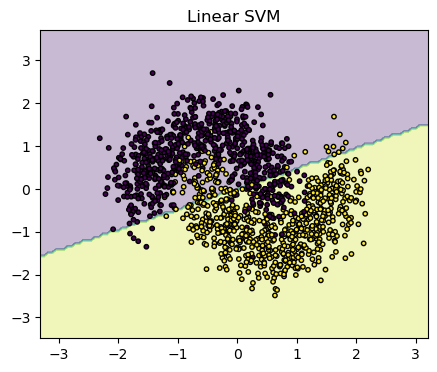

In [ ]:
# Plot the decision region for all four models
fig, ax = plt.subplots(figsize=(5,4))

DecisionBoundaryDisplay.from_estimator(linear_best_model,
                                       X_train_scaled,
                                       ax=ax,
                                       response_method='predict',
                                       alpha=0.3)

ax.scatter(X_train_scaled[:,0],
           X_train_scaled[:,1],
           c = y_train,
           s = 10,
           edgecolors = 'k'
           )

ax.set_title('Linear SVM')
plt.show()

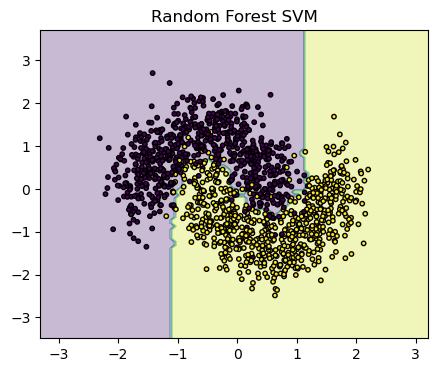

In [ ]:
# Plot the decision boundary for Random Forest
fig, ax = plt.subplots(figsize=(5, 4))

DecisionBoundaryDisplay.from_estimator(
    rf_best_model,
    X_train_scaled,
    ax=ax,
    response_method='predict',
    alpha=0.3
)

ax.scatter(X_train_scaled[:, 0],
           X_train_scaled[:, 1],
           c=y_train,
           s=10,
           edgecolors='k')

ax.set_title('Random Forest SVM')
plt.show()

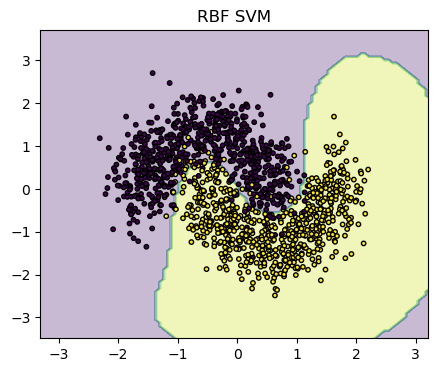

In [ ]:
# Plot the decision boundary for RBF
fig, ax = plt.subplots(figsize=(5, 4))

DecisionBoundaryDisplay.from_estimator(
    rbf_best_model,
    X_train_scaled,
    ax=ax,
    response_method='predict',
    alpha=0.3
)

ax.scatter(X_train_scaled[:, 0],
           X_train_scaled[:, 1],
           c=y_train, s=10,
           edgecolors='k')

ax.set_title('RBF SVM')
plt.show()

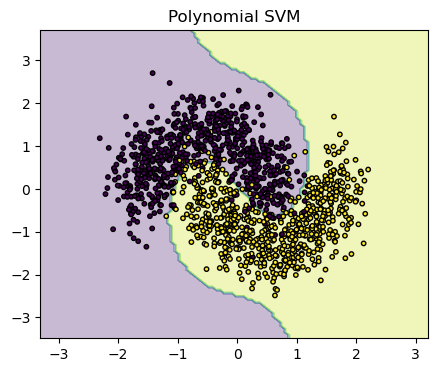

In [ ]:
# Plot the decision boundary for polynomial SVM
fig, ax = plt.subplots(figsize=(5, 4))

DecisionBoundaryDisplay.from_estimator(
    poly_best_model,
    X_train_scaled,
    ax=ax,
    response_method='predict',
    alpha=0.3
)

ax.scatter(X_train_scaled[:, 0],
           X_train_scaled[:, 1],
           c=y_train,
           s=10,
           edgecolors='k')

ax.set_title('Polynomial SVM')
plt.show()

> **Q6: How does the linear kernel's decision boundary compare visually to the RBF, polynomial, and Random Forest boundaries? How does the Random Forest boundary differ from the SVM boundaries?**

The linear kernel’s decision boundary is a single straight, angled line, which cuts across the moons without following their curved structure. It essentially tries to separate the classes with one flat split, which is why it misclassifies the inner arc of data points. In contrast, the RBF and polynomial kernels both produce curved boundaries that adjust around the half‑moon shapes. The RBF boundary is the smoothest as it bends tightly around each cluster. The polynomial boundary also curves, but in a broader way, since the polynomial degree controls how curvy the boundary can be. The Random Forest boundary looks different from all the SVM boundaries because instead of one smooth curve, it breaks the space into rectangular regions.

---

## Step 9: Model Comparison


### Confusion Matrices 

Accuracy alone can hide where models differ in their error patterns. Confusion matrices break down false positives and false negatives. 

##### Create a confusion matrix for each of the four models above. 

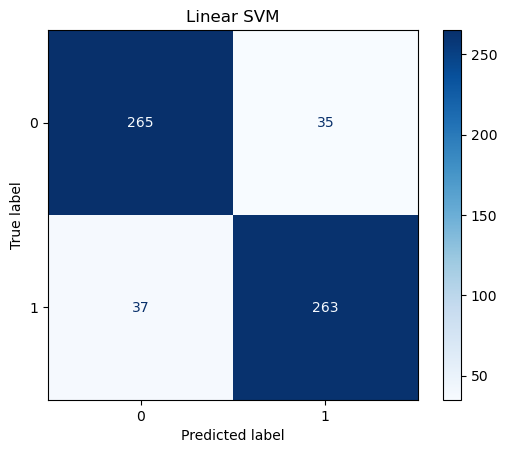

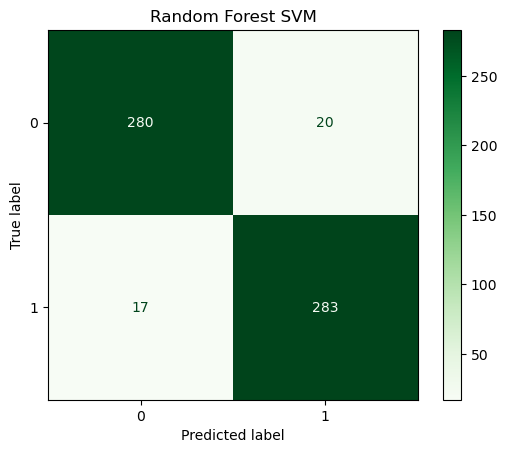

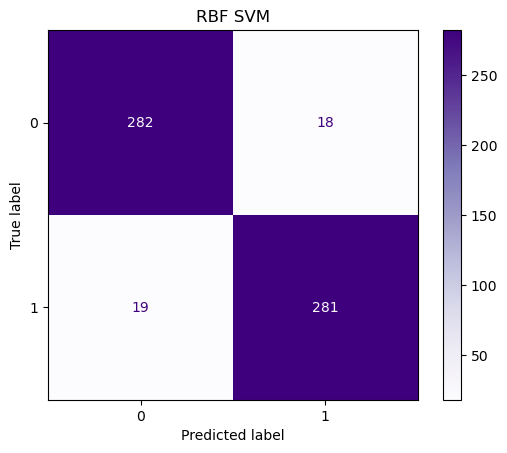

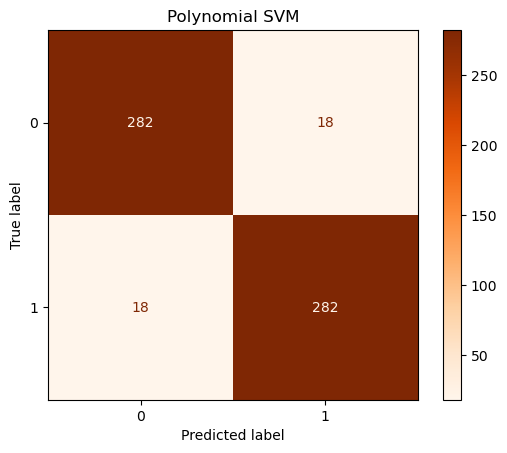

<Figure size 640x480 with 0 Axes>

In [14]:
# Create a confusion matrix for the linear model
ConfusionMatrixDisplay.from_estimator(linear_best_model,
                                      X_test_scaled,
                                      y_test,
                                      cmap="Blues").ax_.set_title("Linear SVM")

# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_best_model,
                                      X_test_scaled,
                                      y_test,
                                      cmap="Greens").ax_.set_title("Random Forest SVM")

# RBF Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rbf_best_model,
                                      X_test_scaled,
                                      y_test,
                                      cmap="Purples").ax_.set_title("RBF SVM")

# Polynomial Confusion Matrix
ConfusionMatrixDisplay.from_estimator(poly_best_model,
                                      X_test_scaled,
                                      y_test,
                                      cmap="Oranges").ax_.set_title("Polynomial SVM")

plt.show()
plt.tight_layout()

>**Q7:Comment on the results of the confusion matrices. Did all four models have similar misclassifications?**

All four models make mistakes in the same overlapping region between the two moons, but they differ in how many errors they make. The linear SVM performs the worst, with 72 total misclassifications, because its straight decision boundary cannot follow the curved structure of the data. In contrast, the RBF SVM (37 errors), polynomial SVM (36 errors), and Random Forest (37 errors) all achieve very similar error counts. These three models produce flexible nonlinear boundaries that better match the crescent shapes, which is why their confusion matrices look nearly identical. In conclusion, the nonlinear models behave similarly to each other, while the linear model stands out as the only one with substantially more misclassifications.

### ROC Curves

The **ROC (Receiver Operating Characteristic)** curve plots the true positive rate against the false positive rate as the classification threshold varies. A random classifier follows the diagonal (AUC = 0.50); a perfect classifier has AUC = 1.0.

**AUC (Area Under the Curve)** summarizes the entire ROC curve in a single number that makes it easy to compare different models.

**How ROC works for SVMs specifically:**
Unlike logistic regression, a standard SVC does not output class probabilities. Instead, it computes a decision function — the signed distance of each observation from the decision boundary. Points far on the positive side get large positive scores; points far on the negative side get large negative scores. `RocCurveDisplay.from_estimator` uses this decision function to build the ROC curve.

This means the ROC curve reflects how well each kernel's decision function ranks observations, independent of where the hard boundary is drawn.

##### Plot the ROC Curves for each of the four models on the same plot. Add a line indicating a random classifier (ACU = 0.5) and a legend. 


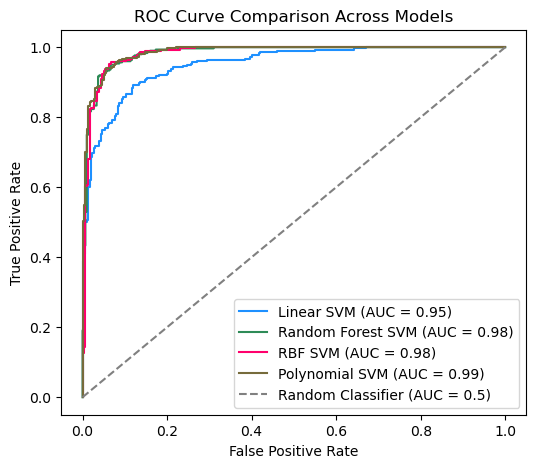

<Figure size 640x480 with 0 Axes>

In [15]:
# Create ROC curve for the linear model
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(linear_best_model,
                               X_test_scaled,
                               y_test,
                               name="Linear SVM",
                               ax=ax,
                               color='DodgerBlue')

# Create ROC curve for the random forest model
RocCurveDisplay.from_estimator(
    rf_best_model,
    X_test_scaled,
    y_test,
    name="Random Forest SVM",
    ax=ax,
    color='seagreen',
)

# Create ROC curve for the RBF SVM
RocCurveDisplay.from_estimator(
    rbf_best_model,
    X_test_scaled,
    y_test,
    name="RBF SVM",
    ax=ax,
    color='#ff006c',
)

# Create ROC curve for the polynomial SVM
RocCurveDisplay.from_estimator(
    poly_best_model,
    X_test_scaled,
    y_test,
    name="Polynomial SVM",
    ax=ax,
    color='#766b3b',
)

# Add a random classifier line (AUC = 0.5)
ax.plot([0, 1], [0, 1],
        linestyle='--',
        color='gray',
        label='Random Classifier (AUC = 0.5)')
plt.title("ROC Curve Comparison Across Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

ax.legend()
plt.show()
plt.tight_layout()

> **Q8: Do the AUC values align with what you observed in the confusion matrices and accuracy scores? How does the Random Forest compare to the SVM kernels across all three metrics? Considering accuracy, AUC, and the decision boundary shape, which model would you choose for this dataset and why?**

Yes, the AUC values align with what we observed in the confusion matrices and accuracy scores. The ROC curves effectively rank the models. The Polynomial SVM performs best with an AUC of 0.99, followed closely by both the RBF SVM and the Random Forest, each with an AUC of 0.98. The Linear SVM has the lowest AUC at 0.95, which is consistent with its higher misclassification count and its inability to model the curved moons boundary. Across all three metrics (accuracy, confusion matrices, and AUC),the nonlinear models (Polynomial SVM, RBF SVM, and Random Forest) clearly outperform the linear SVM. Among them, the Polynomial SVM has the slight edge in AUC, while the RBF SVM and Random Forest tie closely behind and show nearly identical error patterns. Considering accuracy, AUC, and the shape of the decision boundaries, any of the nonlinear models would be a strong choice, but the Polynomial SVM is the model I would choose for this dataset based on it's AUC.

>**Q9: In terms of overall performance, why does the linear kernel not perform as well as the RBF kernel, Polynomial Kernel, or Random Forest. What is a difference between these latter three models and the former that impacts the shape of the decision boundary and overall accuracy.**

The linear kernel performs worse because it can only produce a single straight decision boundary. On the moons dataset, this boundary cuts through both arcs and misses the curved structure of the classes. In contrast, the RBF kernel, polynomial kernel, and Random Forest all produce non‑linear boundaries. The RBF kernel adapts and forms a smooth curve around each moon, the polynomial kernel creates more globally curved boundaries, and the Random Forest forms a flexible, more piecewise boundary. This additional flexibility allows these models to follow the crescent shape of the data and achieve higher accuracy.